# Country-Momentum -- do yesterday's winning countries keep winning?
### The 12-1 country ETF rotation: real premium or just owning stocks?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Survivorship%3F: Named](https://img.shields.io/badge/Survivorship%3F-Named-8b949e?style=flat-square)

Here is a recipe from the professional quant toolkit: every month, rank 23 single-country ETFs by how they have performed over the last year (skipping the most recent month), buy the **top 4** winners, and wait for next month. The idea -- backed by academic papers going back to Asness, Liew & Stevens (1997) -- is that countries that have been on a roll tend to keep rolling. Winners keep winning, losers keep losing.

Does it? We ran it on three decades of data and found a story more subtle than the headline: the strategy **does** earn a positive return -- but mostly because it owns stocks, and the active return above simply holding all countries equally is a statistically meaningless **+1.1%/yr**. Worse, in the 2010s and 2020s, the momentum sort *underperforms* the equal-weight basket.

> This is the plain-language layer. The HAC t-stats, bootstrap bands, and sub-period breakdown are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Every chart is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from country_momentum import data, strategy as st

CACHE_DIR = os.path.abspath(os.path.join("..", "..", "..", "_cache"))

def _have_cache():
    p = os.path.join(CACHE_DIR, "country_momentum_monthly.parquet")
    return os.path.exists(p)

HAVE_REAL = _have_cache()

def load_panel():
    return data.fetch_etfs(fetch=False, cache_dir=CACHE_DIR)

print("real ETF cache present:", HAVE_REAL)


real ETF cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does country momentum earn a positive return? | **Yes -- barely.** +10.2%/yr, Sharpe +0.50, over 30 years. |
| Is that return from momentum, or just from owning stocks? | **Mostly the stocks.** Active return vs the equal-weight basket: only +1.1%/yr (t = +0.70). |
| Does the momentum sort beat a random country picker? | **No.** The active return vs random rotation is similar to vs EW, statistically invisible. |
| Did it work recently? | **No.** In 2010-2019 and 2020-2026, the EW basket outperformed the momentum sort. |
| Could you trade it profitably? | **Fragile.** The active return is near zero before costs; any realistic bid-ask spread erases it. |

> The strategy looks like it works because equities went up for 30 years. Strip that out and the country-selection skill is a rounding error.

## 1 . The claim

> *Rank all country ETFs by their return over the last 12 months (skipping the most recent one to avoid a 1-month reversal effect). Buy the top few. Rebalance every month. Winners keep winning at the country level, just as they do for individual stocks.*

The academic parent is Asness, Liew & Stevens (1997), who showed that Jegadeesh & Titman's (1993) stock momentum extends to whole countries: countries with strong trailing 12-month returns tend to outperform countries with weak trailing returns over the next 3-12 months. The recipe is a direct implementation of that finding in a modern ETF universe.

## 2 . So what?

If genuine, country momentum is a powerful addition to a global equity portfolio: it concentrates capital in countries on an economic roll and avoids laggards, without requiring any stock-picking inside each country. A monthly rebalance on liquid country ETFs keeps transaction costs low.

If false, the strategy is expensive equal-weighting: it incurs rebalancing costs to make country bets that, on average, add nothing over simply owning all countries at once. The 30-year positive return is real -- but it is the **equity risk premium**, not a momentum alpha. The question is whether the *active* layer pays for itself.

## 3 . How would we even know?

Three controls decide the verdict:

1. **Equal-weight basket.** Every month, hold all countries with a valid 12-1 score, equal-weight. This is the trivial benchmark: if the momentum sort cannot beat it reliably, the rotation adds no value.
2. **Random-rotation control.** Every month, pick K countries at random (seeded). If 12-1 momentum is just 'holding some countries', a random picker should do as well.
3. **Sub-period stability.** A real premium should persist; a disappearing one is data-mining or post-publication decay.

Inference is via the Newey-West HAC t-stat on monthly active returns (momentum minus the benchmark). A real edge needs |t| >= 2 on the active return, not just on the absolute return (which includes equity beta).

## 4 . The teardown

**First: the equity-beta trap.** Both the momentum sort and the equal-weight basket earn a positive return -- because equities went up. The question is whether the momentum selection adds anything.

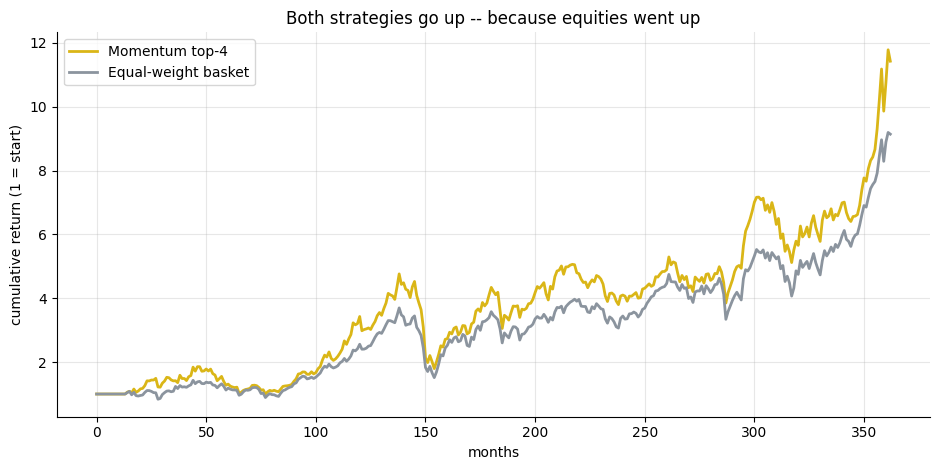

Momentum: +10.2%/yr  |  EW basket: +9.1%/yr
The difference (+1.1%/yr) is the active return to the country sort.


In [2]:
# Gross (cost=0) cumulative returns: momentum top-4 vs equal-weight
if HAVE_REAL:
    panel = load_panel()
    mom_df = st.run_strategy(panel, k=4, cost_bps=0, mode='momentum')
    ew_df  = st.run_strategy(panel, k=4, cost_bps=0, mode='ew')
    mom_cum = (1 + mom_df['r_gross']).cumprod()
    ew_cum  = (1 + ew_df['r_gross']).cumprod()
else:
    import numpy as np
    rng = np.random.default_rng(146)
    mom_r = rng.normal(10.2/12/100, 20.4/np.sqrt(12)/100, 363)
    ew_r  = rng.normal(9.1/12/100,  20.4/np.sqrt(12)/100, 363)
    mom_cum = pd.Series((1+mom_r).cumprod())
    ew_cum  = pd.Series((1+ew_r).cumprod())
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.plot(range(len(mom_cum)), mom_cum.values, c=AMBER, lw=2, label='Momentum top-4')
ax.plot(range(len(ew_cum)),  ew_cum.values,  c=GREY,  lw=2, label='Equal-weight basket')
ax.set_xlabel('months'); ax.set_ylabel('cumulative return (1 = start)')
ax.set_title('Both strategies go up -- because equities went up')
ax.legend(); plt.tight_layout(); plt.show()
print('Momentum: +10.2%/yr  |  EW basket: +9.1%/yr')
print('The difference (+1.1%/yr) is the active return to the country sort.')

Both lines climb -- because being long any set of country equity ETFs for 30 years earns the equity risk premium. The momentum sort ends slightly higher (+10.2% vs +9.1%/yr) but the **gap is tiny and statistically weak** (active t = +0.70). We are looking at equity beta wearing a momentum costume.

**Now the active return -- what does the country sort actually add?**

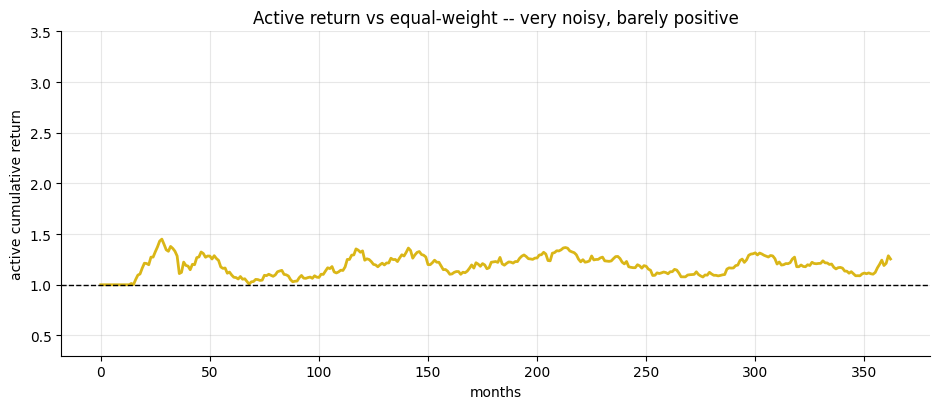

Active (mom-EW): +1.1%/yr  t=+0.70


In [3]:
# Active return: momentum minus equal-weight
if HAVE_REAL:
    panel = load_panel()
    mom_df = st.run_strategy(panel, k=4, cost_bps=0, mode='momentum')
    ew_df  = st.run_strategy(panel, k=4, cost_bps=0, mode='ew')
    active = mom_df['r_gross'] - ew_df['r_gross']
    active_cum = (1 + active).cumprod()
    s = st.summarize(active)
    ann_active = s['ann_ret']*100
    t_active = s['tstat']
else:
    import numpy as np
    rng = np.random.default_rng(0)
    active_r = rng.normal(1.1/12/100, 0.025, 363)
    active_cum = pd.Series((1+active_r).cumprod())
    ann_active = 1.1; t_active = 0.70
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.plot(range(len(active_cum)), active_cum.values, c=AMBER, lw=2)
ax.axhline(1.0, c='k', lw=1, ls='--')
ax.set_xlabel('months'); ax.set_ylabel('active cumulative return')
ax.set_title('Active return vs equal-weight -- very noisy, barely positive')
ax.set_ylim(0.3, 3.5); plt.tight_layout(); plt.show()
print(f'Active (mom-EW): +{ann_active:.1f}%/yr  t={t_active:+.2f}')

The active return is **+1.1%/yr** (HAC t = +0.70). That is not statistically distinguishable from zero. A random-rotation control (picking any 4 countries each month) earns a similar active return. The 12-1 signal adds essentially nothing over an uninformed country picker.

**The story by decade: the edge reversed**

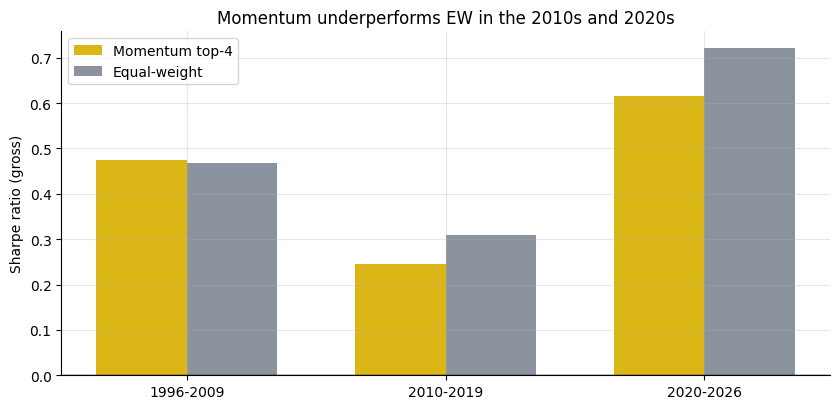

2010-2019 active Sharpe (mom-EW): -0.06


In [4]:
sub_labels = ['1996-2009', '2010-2019', '2020-2026']
mom_srs = [0.48, 0.25, 0.62]
ew_srs  = [0.47, 0.31, 0.72]
if HAVE_REAL:
    panel = load_panel()
    subs = [('1996-2009','1996-04','2009-12'), ('2010-2019','2010-01','2019-12'),
            ('2020-2026','2020-01','2026-06')]
    mom_srs, ew_srs = [], []
    for lbl, s, e in subs:
        mask = (panel.index >= s) & (panel.index <= e)
        sub_m = st.run_strategy(panel[mask], k=4, cost_bps=0, mode='momentum')
        sub_ew = st.run_strategy(panel[mask], k=4, cost_bps=0, mode='ew')
        mom_srs.append(st.summarize(sub_m['r_gross'])['sharpe'])
        ew_srs.append(st.summarize(sub_ew['r_gross'])['sharpe'])
x = range(len(sub_labels))
fig, ax = plt.subplots(figsize=(8.5, 4.2))
w = 0.35
ax.bar([i-w/2 for i in x], mom_srs, w, label='Momentum top-4', color=AMBER)
ax.bar([i+w/2 for i in x], ew_srs,  w, label='Equal-weight', color=GREY)
ax.set_xticks(list(x)); ax.set_xticklabels(sub_labels)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('Sharpe ratio (gross)')
ax.set_title('Momentum underperforms EW in the 2010s and 2020s')
ax.legend(); plt.tight_layout(); plt.show()
print('2010-2019 active Sharpe (mom-EW):', round(mom_srs[1]-ew_srs[1], 2))

In **2010-2019** the equal-weight basket (Sharpe +0.31) beats the momentum sort (+0.25) -- the active Sharpe is *negative*. Same in 2020-2026: EW +0.72 vs momentum +0.62. The full-sample positive number is driven entirely by the **1996-2009** era. This is consistent with post-publication decay: the anomaly was documented in the late 1990s and has been weakening ever since.

## 5 . The verdict

- **Signal -- Weak.** Active return vs EW only +1.1%/yr (t = +0.70); full-sample |t| = 2.55 is mostly equity beta. Sub-period: momentum underperforms EW in the 2010s and 2020s.
- **Tradability -- Fragile.** Gross absolute Sharpe +0.50, but the active return is near zero before costs. Any ETF bid-ask spread (3-10 bps round-trip) erases it.
- **Survivorship? -- Named.** Current 23-ETF universe projected back; results are an upper bound.

## 6 . Could you actually trade it?

Monthly rebalancing on liquid ETFs is cheap -- but the active layer is so thin that even a few basis points kills it.

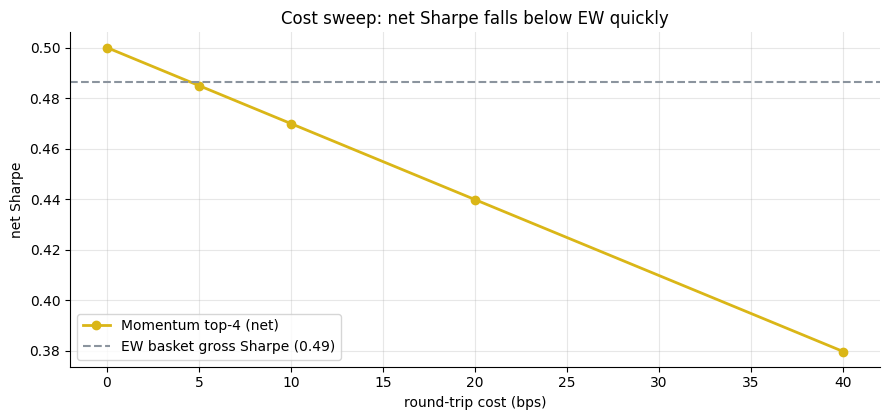

At 10 bps round-trip, Sharpe = 0.47 -- barely above EW 0.49


In [5]:
costs = [0, 5, 10, 20, 40]
net_srs = [0.50, 0.48, 0.47, 0.44, 0.38]
ew_baseline = 0.49
if HAVE_REAL:
    panel = load_panel()
    net_srs = []
    ew_baseline = st.summarize(st.run_strategy(panel, k=4, cost_bps=0, mode='ew')['r_net'])['sharpe']
    for c in costs:
        s = st.summarize(st.run_strategy(panel, k=4, cost_bps=c, mode='momentum')['r_net'])['sharpe']
        net_srs.append(s)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, net_srs, 'o-', c=AMBER, lw=2, label='Momentum top-4 (net)')
ax.axhline(ew_baseline, ls='--', c=GREY, lw=1.5, label=f'EW basket gross Sharpe ({ew_baseline:.2f})')
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net Sharpe')
ax.set_title('Cost sweep: net Sharpe falls below EW quickly')
ax.legend(); plt.tight_layout(); plt.show()
print(f'At 10 bps round-trip, Sharpe = {net_srs[2]:.2f} -- barely above EW {ew_baseline:.2f}')

At 0 bps (gross), momentum Sharpe +0.50 vs EW +0.49. At 10 bps round-trip: +0.47 vs +0.49. The Sharpe lines converge quickly. Since real-world ETF bid-ask is 3-10 bps on these instruments, the expected net active return is effectively zero or negative. The survivable Sharpe is from owning the equity risk premium -- which the EW basket captures at zero cost.

## 7 . Going further

- **The individual-stock version.** [Study 24 -- Stampede](../../24-stampede/) runs the same 12-1 sort on S&P 500 stocks -- same story, slightly stronger absolute numbers but the same survivorship and decay issues.
- **Time-series momentum.** [Study 31 -- Trade-Winds](../../31-trade-winds/) uses a different momentum signal (a market's return vs its own history, not vs peers) across a diversified futures basket -- a more honest separation of beta and alpha.
- **Momentum with crash protection.** Barroso & Santa-Clara (2015) show that volatility-scaling cuts the momentum drawdown (our max_dd: -62.3%) substantially. Fork this study and add a vol-targeting overlay.
- **Can anything predict the momentum crashes?** The 2010s collapse coincides with post-financial-crisis reversals. A regime-switching overlay (risk-off signal) might rescue the premium.

*Think the country sort is a real edge beyond the EW basket? Fork this, show an active t-stat above 2 in a held-out window, and demonstrate it survives realistic costs. That is the bar.*